In [17]:
import os
import lightkurve as lk
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from astropy.io import ascii
plt.rcParams['axes.formatter.min_exponent'] = 4

from mpl_toolkits.axes_grid1.inset_locator import inset_axes


plt.rcParams.update({'font.size': 18}) # 16
plt.rcParams.update({'legend.fontsize': 18}) # medium
plt.rcParams.update({'axes.linewidth': 2.0})
plt.rcParams.update({'lines.linewidth': 2.0})
plt.rcParams.update({'patch.linewidth': 2.0})
plt.rcParams.update({'xtick.major.size': 8.0})
plt.rcParams.update({'xtick.minor.size': 4.0})
plt.rcParams.update({'ytick.major.size': 8.0})
plt.rcParams.update({'ytick.minor.size': 4.0})
plt.rcParams.update({'xtick.major.width': 1.0})
plt.rcParams.update({'xtick.minor.width': 1.0})
plt.rcParams.update({'ytick.major.width': 1.0})
plt.rcParams.update({'ytick.minor.width': 1.0})
plt.rcParams.update({'lines.markeredgewidth': 2.0})

In [3]:
#TICv8 (468064 stars)
pd.set_option('display.max_columns', None)
tic = "./TOI_Mar2025.csv"
tic = pd.read_csv(tic)
print(list(tic.columns))

t_tic_id = tic['tid']
t_teff = tic['st_teff']
t_rstar = tic['st_rad']
print(len(tic))


['toi', 'tid', 'tfopwg_disp', 'rastr', 'ra', 'decstr', 'dec', 'st_pmra', 'st_pmraerr1', 'st_pmraerr2', 'st_pmralim', 'st_pmdec', 'st_pmdecerr1', 'st_pmdecerr2', 'st_pmdeclim', 'pl_tranmid', 'pl_tranmiderr1', 'pl_tranmiderr2', 'pl_tranmidlim', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_trandurh', 'pl_trandurherr1', 'pl_trandurherr2', 'pl_trandurhlim', 'pl_trandep', 'pl_trandeperr1', 'pl_trandeperr2', 'pl_trandeplim', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_insol', 'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'st_tmag', 'st_tmagerr1', 'st_tmagerr2', 'st_tmaglim', 'st_dist', 'st_disterr1', 'st_disterr2', 'st_distlim', 'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_logg', 'st_loggerr1', 'st_loggerr2', 'st_logglim', 'st_rad', 'st_raderr1', 'st_raderr2', 'st_radlim', 'toi_created', 'rowupdate', 'cdpp']
7372


#merged catalog
import radius_valley_bioverse as rv
file = "/home/harshitha/Downloads/RV/new_merged_catalog_april18.csv"
radius, radius_fp, radius_period, period, period_fp, period_period, teff = rv.radius_values(file,"radius")
mradius, mradius_fp, mradius_period, mperiod, mperiod_fp, mperiod_period, mteff = rv.radius_values(file,"mradius")
kradius, kradius_fp, kradius_period, kperiod, kperiod_fp, kperiod_period, kteff = rv.radius_values(file,"kradius")
gradius, gradius_fp, gradius_period, gperiod, gperiod_fp, gperiod_period,gteff = rv.radius_values(file,"gradius")

In [4]:
koi_c = "./kepler candidates.csv"
koi_c = pd.read_csv(koi_c,header=55)
print(koi_c.columns)

koi_c_teff = koi_c['koi_steff']
print(len(koi_c_teff))

Index(['kepid', 'kepoi_name', 'kepler_name', 'koi_disposition',
       'koi_pdisposition', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss',
       'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_period_err1',
       'koi_period_err2', 'koi_time0bk', 'koi_time0bk_err1',
       'koi_time0bk_err2', 'koi_impact', 'koi_impact_err1', 'koi_impact_err2',
       'koi_duration', 'koi_duration_err1', 'koi_duration_err2', 'koi_depth',
       'koi_depth_err1', 'koi_depth_err2', 'koi_prad', 'koi_prad_err1',
       'koi_prad_err2', 'koi_teq', 'koi_teq_err1', 'koi_teq_err2', 'koi_insol',
       'koi_insol_err1', 'koi_insol_err2', 'koi_model_snr', 'koi_tce_plnt_num',
       'koi_tce_delivname', 'koi_steff', 'koi_steff_err1', 'koi_steff_err2',
       'koi_slogg', 'koi_slogg_err1', 'koi_slogg_err2', 'koi_srad',
       'koi_srad_err1', 'koi_srad_err2', 'ra', 'dec', 'koi_kepmag'],
      dtype='object')
1982


In [5]:
k2 = "./k2.csv"
k2 = pd.read_csv(k2,header=128)
print(k2.columns)

k2_teff = k2['st_teff']
k2_teff = k2_teff[(k2['disposition'] != 'FALSE POSITIVE')]
print(len(k2_teff))
#k2_teff_rad = k2_teff[(k2['pl_rade']<4)]

#k_teff = k2['st_teff'].concat(koi_all['koi_steff'])  

kepler = './kepler_2025.csv'
kepler = pd.read_csv(kepler, header=55)
print(kepler.columns)
print(len(kepler))

Index(['pl_name', 'hostname', 'tic_id', 'gaia_id', 'default_flag',
       'disposition', 'disp_refname', 'sy_snum', 'sy_pnum', 'discoverymethod',
       ...
       'sy_gaiamagerr2', 'sy_tmag', 'sy_tmagerr1', 'sy_tmagerr2', 'sy_kepmag',
       'sy_kepmagerr1', 'sy_kepmagerr2', 'rowupdate', 'pl_pubdate',
       'releasedate'],
      dtype='object', length=122)
3550
Index(['kepid', 'kepoi_name', 'kepler_name', 'koi_disposition',
       'koi_pdisposition', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss',
       'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_period_err1',
       'koi_period_err2', 'koi_time0bk', 'koi_time0bk_err1',
       'koi_time0bk_err2', 'koi_impact', 'koi_impact_err1', 'koi_impact_err2',
       'koi_duration', 'koi_duration_err1', 'koi_duration_err2', 'koi_depth',
       'koi_depth_err1', 'koi_depth_err2', 'koi_prad', 'koi_prad_err1',
       'koi_prad_err2', 'koi_teq', 'koi_teq_err1', 'koi_teq_err2', 'koi_insol',
       'koi_insol_err1', 'koi_insol_err2', 'koi_mode

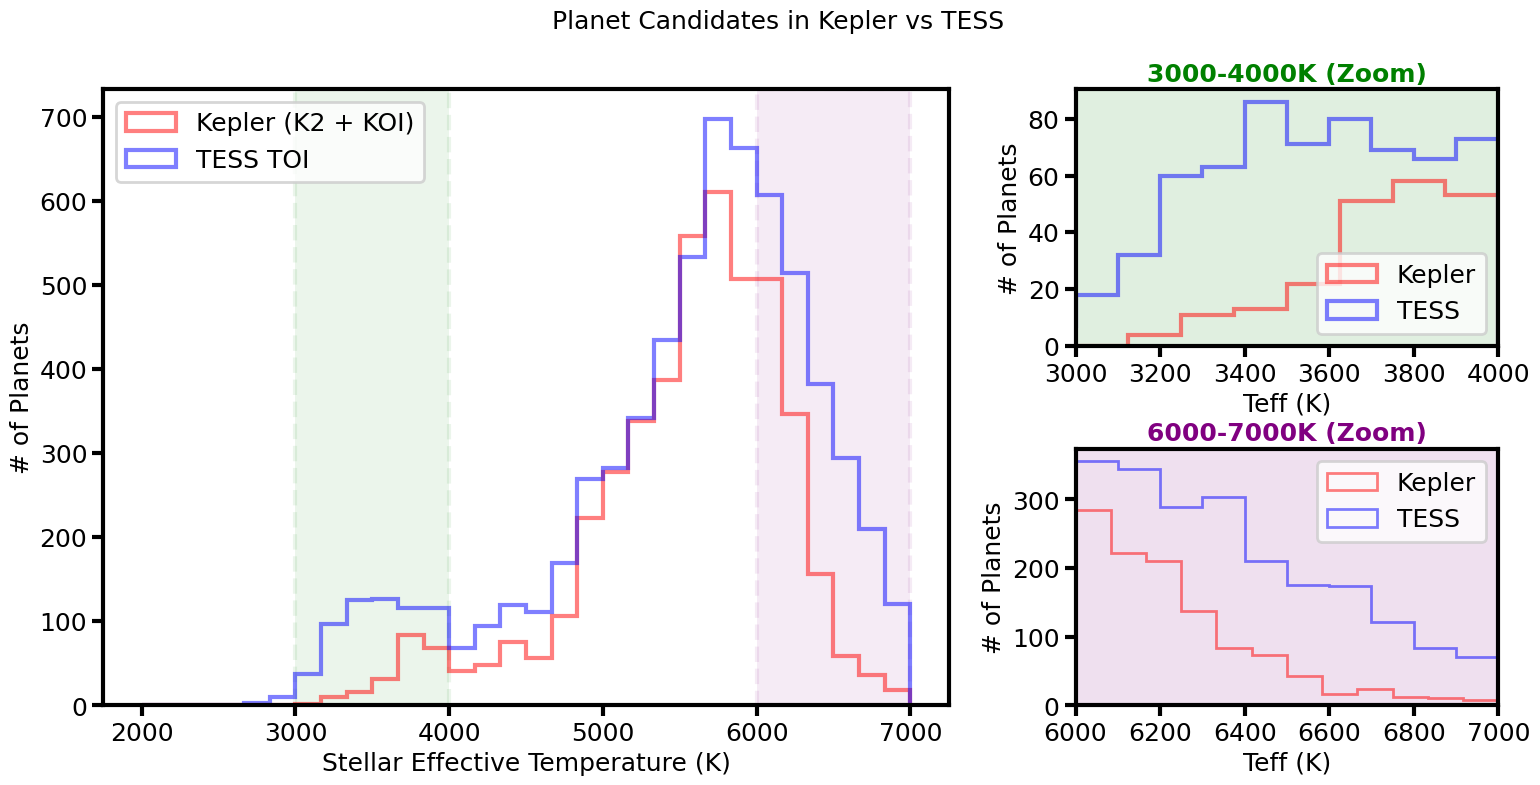

In [18]:
#plt.hist(k2['st_teff'],bins=30,range=(2000,8000),alpha=0.5,label='K2 candidates',color='orange')
#plt.hist(koi_c['koi_steff'],bins=30,range=(2000,8000),alpha=0.5,label='Kepler candidates',color='green')

from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

fig = plt.figure(figsize=(18, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[2, 1], height_ratios=[1, 1], hspace=0.4, wspace=0.2)
plt.rcParams.update({'lines.linewidth': 3, 'axes.linewidth': 3, 'grid.linewidth': 3, 'xtick.major.width': 3, 'ytick.major.width': 3, 'xtick.minor.width': 3, 'ytick.minor.width': 3})


# Main plot on the left spanning both rows
ax1 = fig.add_subplot(gs[:, 0])
ax1.hist(kepler['koi_steff'], bins=30, range=(2000,7000), alpha=0.5, label='Kepler (K2 + KOI)', color='red', histtype='step', linewidth=3)
ax1.hist(tic['st_teff'], bins=30, range=(2000,7000), alpha=0.5, label='TESS TOI', color='blue', histtype='step', linewidth=3)
ax1.set_xlabel('Stellar Effective Temperature (K)')
ax1.set_ylabel('# of Planets')
ax1.legend()

# Get y-axis limits for the highlighting rectangles
ylim = ax1.get_ylim()

# Add semi-transparent rectangles to highlight the regions being zoomed
# Cool stars region (3000-4000K) - for top right inset
rect_cool = Rectangle((3000, ylim[0]), 1000, ylim[1]-ylim[0], 
                       linewidth=3, edgecolor='green', facecolor='green', 
                       alpha=0.08, linestyle='--', label='Zoom region')
ax1.add_patch(rect_cool)

# Hot stars region (6000-7000K) - for bottom right inset
rect_hot = Rectangle((6000, ylim[0]), 1000, ylim[1]-ylim[0], 
                      linewidth=3, edgecolor='purple', facecolor='purple', 
                      alpha=0.08, linestyle='--')
ax1.add_patch(rect_hot)

# Inset for cool stars (3000-4000K) - top right
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(kepler['koi_steff'], bins=12, range=(2500,4000), alpha=0.5, 
         label='Kepler', color='red', histtype='step', linewidth=3)
ax2.hist(tic['st_teff'], bins=15, range=(2500,4000), alpha=0.5, 
         label='TESS', color='blue', histtype='step', linewidth=3)
ax2.set_xlabel('Teff (K)')
ax2.set_ylabel('# of Planets')
ax2.set_title('3000-4000K (Zoom)', fontsize=18, color='green', fontweight='bold')
ax2.legend(fontsize=18)
ax2.set_xlim(3000, 4000)
# Add light green background shading
ax2.patch.set_facecolor('green')
ax2.patch.set_alpha(0.12)

# Inset for hot stars (6000-7000K) - bottom right
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(kepler['koi_steff'], bins=12, range=(6000,7000), alpha=0.5, 
         label='Kepler', color='red', histtype='step', linewidth=2)
ax3.hist(tic['st_teff'], bins=10, range=(6000,7000), alpha=0.5, 
         label='TESS', color='blue', histtype='step', linewidth=2)
ax3.set_xlabel('Teff (K)')
ax3.set_ylabel('# of Planets')
ax3.set_title('6000-7000K (Zoom)', fontsize=18, color='purple', fontweight='bold')
ax3.legend(fontsize=18)
ax3.set_xlim(6000, 7000)
# Add light purple background shading
ax3.patch.set_facecolor('purple')
ax3.patch.set_alpha(0.12)

plt.suptitle('Planet Candidates in Kepler vs TESS', fontsize=18, y=0.98)
plt.tight_layout()

plt.savefig('teff_comparison_kepler_tess.png', dpi=300, bbox_inches='tight')